![Los Angeles skyline](../images/la_skyline.jpg)

Los Angeles, California 😎. The City of Angels. Tinseltown. The Entertainment Capital of the World! 

Known for its warm weather, palm trees, sprawling coastline, and Hollywood, along with producing some of the most iconic films and songs. However, as with any highly populated city, it isn't always glamorous and there can be a large volume of crime.

## The Scenario

We've been asked to support the Los Angeles Police Department (LAPD) by analyzing crime data to identify patterns in criminal behavior. They plan to use your insights to allocate resources effectively to tackle various crimes in different areas.

## The Data

This dataset was downloaded from [DataCamp](https://www.datacamp.com/) in April 2024 which was extracted and modified from the ***Los Angeles - Open Data Portal*** which can be found [here](https://data.lacity.org/Public-Safety/Crime-Data-from-2020-to-2024/2nrs-mtv8/about_data).

***DISCLAIMER: No claims of accuracy on anything are made or implied any part of this analysis.***

A summary and preview are provided below.

# la_crimes.csv

| Column           | Description              |
|:----------------:|:-------------------------|
| `DR_NO`        | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `Date_Rptd`    | Date reported - YYYY-MM-DD. |
| `DATE_OCC`     | Date of occurrence - YYYY-MM-DD. |
| `TIME_OCC`     | In 24-hour military time. |
| `AREA_NAME`    | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `Crm_Cd_Desc` | Indicates the crime committed. |
| `Vict_Age`     | Victim's age in years. |
| `Vict_Sex`     | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `Vict_Descent` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `Weapon_Desc`  | Description of the weapon used (if applicable). |
| `Status_Desc`  | Crime status. |
| `LOCATION`     | Street address of the crime. |

## Research questions for this project

+ Which hour has the highest frequency of crimes?
  - We'll store as an integer variable called `peak_crime_hour`.
+ Which area has the largest frequency of night crimes (crimes committed between 10pm and 3:59am)?
  - We'll store as a string variable called `peak_night_crime_location`.
+ Identify the number of crimes committed against victims of different age groups
  - We'll save this as a pandas Series called `victim_ages`, with age group labels:  
  - `"0-17"`, `"18-25"`, `"26-34"`, `"35-44"`, `"45-54"`, `"55-64"`, and `"65+"`
    as the index and the frequency of crimes as the values.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# parse the 2 date cols on the read
crimes = pd.read_csv("../data/la_crimes.csv", parse_dates=["Date_Rptd", "DATE_OCC"], dtype={"TIME_OCC": str})
crimes.info()
print('\n', crimes.shape, '\n')
crimes.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   DR_NO         185715 non-null  int64         
 1   Date_Rptd     185715 non-null  datetime64[ns]
 2   DATE_OCC      185715 non-null  datetime64[ns]
 3   TIME_OCC      185715 non-null  object        
 4   AREA_NAME     185715 non-null  object        
 5   Crm_Cd_Desc   185715 non-null  object        
 6   Vict_Age      185715 non-null  int64         
 7   Vict_Sex      185704 non-null  object        
 8   Vict_Descent  185705 non-null  object        
 9   Weapon_Desc   73502 non-null   object        
 10  Status_Desc   185715 non-null  object        
 11  LOCATION      185715 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(8)
memory usage: 17.0+ MB

 (185715, 12) 



,DR_NO,Date_Rptd,DATE_OCC,TIME_OCC,AREA_NAME,Crm_Cd_Desc,Vict_Age,Vict_Sex,Vict_Descent,Weapon_Desc,Status_Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


## Data characteristics and quality

### Missing values

At first glance of the 185715 records in this dataset, it looks only 3 columns/fields contain missing data:

+ `Vict_Sex` - missing **11** values
+ `Vict_Descent` - missing **10** values
+ `Weapon_Desc` - missing 185715 - 73502 = **112213** values, most of these are probably not missing so much as a weapon was not involved in the crime

In [2]:
crimes['Vict_Sex'].value_counts()

Vict_Sex
M    93008
F    89854
X     2812
H       30
Name: count, dtype: int64

## Which hour has the highest frequency of crimes? Store as an integer variable called `peak_crime_hour`

The `TIME OCC` column was read in as a string. We'll create a new feature called `HourOcc` which is the first 2 characters of the `TIME OCC` string converted to an int.

Top 5 highest crime count hours of the day:
HourOcc
12    13663
18    10125
17     9964
20     9579
15     9393
Name: count, dtype: int64 



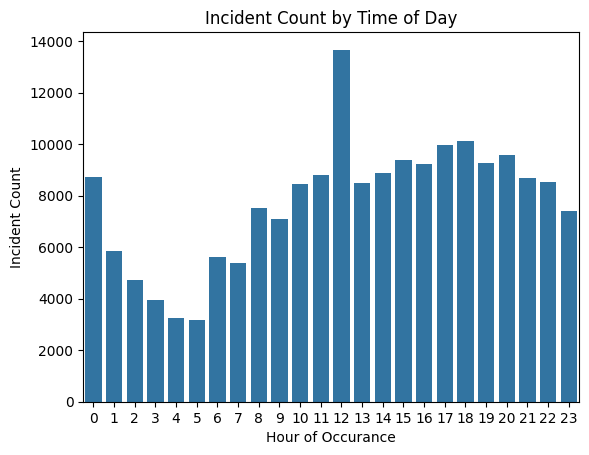

In [3]:
crimes["HourOcc"] = crimes["TIME_OCC"].str[:2].astype(int)
hour_counts = crimes["HourOcc"].value_counts()
print("Top 5 highest crime count hours of the day:")
print(hour_counts[:5], '\n')
g = sns.countplot(data=crimes, x="HourOcc")
g.set_xlabel("Hour of Occurance")
g.set_ylabel("Incident Count")
g.set_title("Incident Count by Time of Day")

plt.show()

In [4]:
peak_crime_hour = hour_counts.index[0]
print(f"Peak crime occurrance hour: {peak_crime_hour}")

Peak crime occurrance hour: 12


## Which area has the largest frequency of night crimes?

*Night crimes* are crimes committed between 10pm and 3:59am. This area will be saved as a string variable called `peak_night_crime_location`.

Start by engineering another new feature we'll call `NightOcc`. This will be a binary variable which we'll use a filter to find the most frequent area. Before we do this, we'll create a new column called `TimeOccInt` which is the `TIME OCC` column converted to an integer.

In [5]:
crimes["TimeOccInt"] = crimes["TIME_OCC"].astype(int)
conditions = [crimes["TimeOccInt"].ge(2200), crimes["TimeOccInt"].le(359)]
choices = [True, True]
crimes["NightOcc"] = np.select(conditions, choices, default=False)
df_night_crimes = crimes[crimes["NightOcc"]]
df_night_crimes.head()

,DR_NO,Date_Rptd,DATE_OCC,TIME_OCC,AREA_NAME,Crm_Cd_Desc,Vict_Age,Vict_Sex,Vict_Descent,Weapon_Desc,Status_Desc,LOCATION,HourOcc,TimeOccInt,NightOcc
8,231207476,2023-02-27,2020-08-15,0001,77th Street,BURGLARY,72,M,B,NaN,Invest Cont,8800 HAAS AV,0,1,True
10,221711184,2022-06-15,2020-05-15,0155,Devonshire,THEFT OF IDENTITY,27,M,B,NaN,Invest Cont,8300 WHITE OAK AV,1,155,True
30,221314362,2022-07-11,2020-04-07,0001,Newton,THEFT OF IDENTITY,53,F,H,NaN,Invest Cont,1600 E OLYMPIC BL,0,1,True
33,231307252,2023-03-03,2020-07-05,2305,Newton,THEFT OF IDENTITY,22,F,B,NaN,Invest Cont,6600 S BROADWAY,23,2305,True
36,221614254,2022-11-13,2020-01-01,0001,Foothill,THEFT OF IDENTITY,22,F,H,NaN,Invest Cont,10200 TELFAIR AV,0,1,True


In [6]:
night_crime_area_counts = df_night_crimes["AREA_NAME"].value_counts()
top_5_night_crime_areas = night_crime_area_counts[:5]
low_5_night_crime_areas = night_crime_area_counts[-5:]
print(f"Number of areas: {len(night_crime_area_counts)}")

Number of areas: 21


In [7]:
# 5 highest and 5 lowest crime areas
df_top_5 = pd.DataFrame(top_5_night_crime_areas).reset_index()
df_low_5 = pd.DataFrame(low_5_night_crime_areas).reset_index()
df_high_low = pd.merge(df_top_5, df_low_5, left_index=True, right_index=True)
df_high_low = df_high_low.rename(columns={"AREA_NAME_x": "High_Crime_Area", "AREA_NAME_y": "Low_Crime_Area",
                                          "count_x": "high_count", "count_y": "low_count"})
df_high_low

,High_Crime_Area,high_count,Low_Crime_Area,low_count
0,Central,3312,Harbor,1384
1,Hollywood,2699,West LA,1369
2,77th Street,2558,Devonshire,1348
3,Southwest,2347,Hollenbeck,1315
4,Southeast,2218,Foothill,1260


AREA_NAME
Central        3312
Hollywood      2699
77th Street    2558
Southwest      2347
Southeast      2218
Name: count, dtype: int64


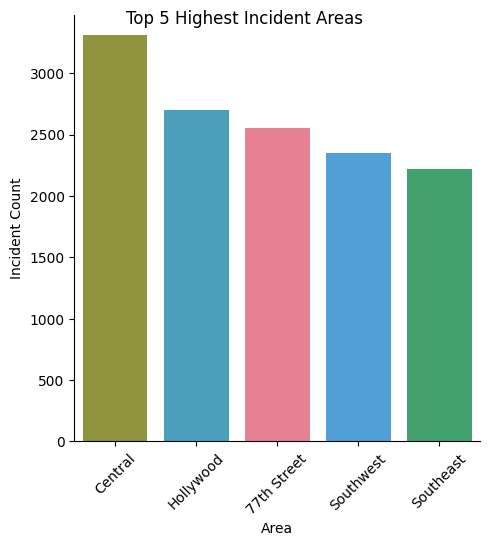

In [8]:
# print(type(top_5_night_crime_areas))  # Series
print(top_5_night_crime_areas)
category_order = top_5_night_crime_areas.index
top_areas_plot = sns.catplot(x="AREA_NAME", data=df_night_crimes, kind="count", order=category_order, hue="AREA_NAME")
top_areas_plot.set_axis_labels("Area", "Incident Count")
top_areas_plot.set_xticklabels(rotation=45)
top_areas_plot.fig.suptitle("Top 5 Highest Incident Areas")
plt.show()

In [9]:
peak_night_crime_location = top_5_night_crime_areas.index[0]
peak_night_crime_location

'Central'

## Identify the number of crimes committed against victims of different age groups

Results will be saved as a pandas Series called `victim_ages`, with age group labels:  
`"0-17"`, `"18-25"`, `"26-34"`, `"35-44"`, `"45-54"`, `"55-64"`, and `"65+"` as the index and the frequency of crimes as the values.

In [10]:
max_age = crimes["Vict_Age"].max()
# print(max_age)  # 99
labels = ["0-17", "18-25", "26-34", "35-44", "45-54", "55-64", "65+"]
bins = [0, 17, 25, 34, 44, 54, 64, max_age]
crimes["VictAgeGroup"] = pd.cut(crimes["Vict_Age"],
                                labels=labels,
                                bins=bins)
crimes.loc[:, ["Vict_Age", "VictAgeGroup"]].head()

,Vict_Age,VictAgeGroup
0,27,26-34
1,60,55-64
2,28,26-34
3,37,35-44
4,79,65+


VictAgeGroup
26-34    47470
35-44    42157
45-54    28353
18-25    28291
55-64    20169
65+      14747
0-17      4528
Name: count, dtype: int64 



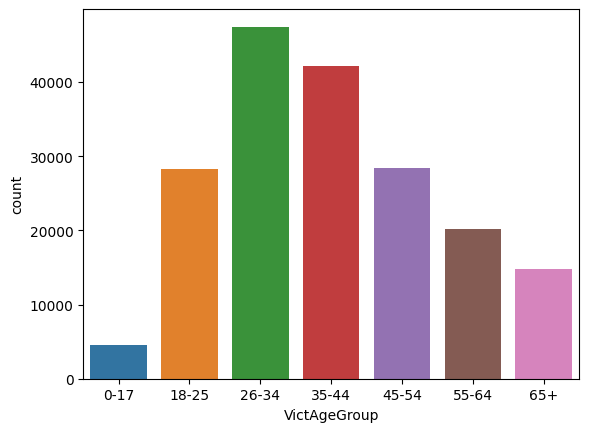

In [11]:
victim_ages = crimes["VictAgeGroup"].value_counts()
print(victim_ages[:7], '\n')
sns.countplot(data=crimes, x="VictAgeGroup", hue="VictAgeGroup")

plt.show()

In [12]:
print(f"Age group with the highest crime frequency in LA during this time period: {victim_ages.index[0]}")

Age group with the highest crime frequency in LA during this time period: 26-34
